# Loading the libraries

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Importing files as DataFrames

In [2]:
'''
since the files are very large(4 Million record per csv) 
I have loaded 2 datasets randomly
'''
all_files = ['/kaggle/input/rainbow-six-siege-s5-ranked-dataset/datadump_s5-003.csv',
             '/kaggle/input/rainbow-six-siege-s5-ranked-dataset/datadump_s5-004.csv']
li = []

for filename in all_files:
    frame = pd.read_csv(filename, index_col=None, header=0)
    li.append(frame)

df = pd.concat(li, axis='rows', ignore_index=True)
df

,dateid,platform,gamemode,mapname,matchid,roundnumber,objectivelocation,winrole,endroundreason,roundduration,...,primarygrip,primaryunderbarrel,primarybarrel,secondaryweapon,secondaryweapontype,secondarysight,secondarygrip,secondaryunderbarrel,secondarybarrel,secondarygadget
0,20170223,PS4,SECURE_AREA,HOUSE,977823561,5,KID'S_BEDROOM,Attacker,DefendersEliminated,185,...,None,None,HeavyBarrel,PRB92,Pistols,None,None,Laser,None,IMPACT_GRENADE
1,20170223,PS4,SECURE_AREA,HOUSE,977823561,1,MASTER_BEDROOM,Attacker,DefendersEliminated,181,...,Vertical,Laser,MuzzleBrake,ITA12S,Shotguns,None,None,None,None,BREACH_CHARGE
2,20170223,PS4,SECURE_AREA,HOUSE,977823561,3,MASTER_BEDROOM,Defender,AttackersEliminated,225,...,None,None,HeavyBarrel,PRB92,Pistols,None,None,Laser,None,IMPACT_GRENADE
3,20170223,PS4,SECURE_AREA,HOUSE,977823561,2,GARAGE,Defender,AttackersEliminated,221,...,Angle,None,Compensator,USP40,Pistols,None,None,None,None,BREACH_CHARGE
4,20170223,PS4,SECURE_AREA,HOUSE,977823561,2,GARAGE,Defender,AttackersEliminated,221,...,Vertical,None,HeavyBarrel,PRB92,Pistols,None,None,None,MuzzleBrake,CLAYMORE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7999995,20170310,XONE,SECURE_AREA,HOUSE,4213607369,6,KID'S_BEDROOM,Defender,AttackersEliminated,186,...,Vertical,Laser,Compensator,P9,Pistols,None,None,None,None,BREACH_CHARGE
7999996,20170310,XONE,SECURE_AREA,HOUSE,4213607369,3,KID'S_BEDROOM,Attacker,DefendersEliminated,160,...,Vertical,None,Compensator,SMG-11,Submachine_Guns,RedDot,Vertical,None,HeavyBarrel,FRAG_GRENADE
7999997,20170310,XONE,SECURE_AREA,HOUSE,4213607369,1,GARAGE,Defender,AttackersEliminated,177,...,None,None,None,P12,Pistols,None,None,None,None,BARBED_WIRE
7999998,20170310,XONE,SECURE_AREA,HOUSE,4213607369,1,GARAGE,Defender,AttackersEliminated,177,...,None,None,None,PRB92,Pistols,None,None,None,None,IMPACT_GRENADE


In [3]:
df.columns

Index(['dateid', 'platform', 'gamemode', 'mapname', 'matchid', 'roundnumber',
       'objectivelocation', 'winrole', 'endroundreason', 'roundduration',
       'clearancelevel', 'skillrank', 'role', 'team', 'haswon', 'operator',
       'nbkills', 'isdead', 'primaryweapon', 'primaryweapontype',
       'primarysight', 'primarygrip', 'primaryunderbarrel', 'primarybarrel',
       'secondaryweapon', 'secondaryweapontype', 'secondarysight',
       'secondarygrip', 'secondaryunderbarrel', 'secondarybarrel',
       'secondarygadget'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000000 entries, 0 to 7999999
Data columns (total 31 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   dateid                int64 
 1   platform              object
 2   gamemode              object
 3   mapname               object
 4   matchid               int64 
 5   roundnumber           int64 
 6   objectivelocation     object
 7   winrole               object
 8   endroundreason        object
 9   roundduration         int64 
 10  clearancelevel        int64 
 11  skillrank             object
 12  role                  object
 13  team                  int64 
 14  haswon                int64 
 15  operator              object
 16  nbkills               int64 
 17  isdead                int64 
 18  primaryweapon         object
 19  primaryweapontype     object
 20  primarysight          object
 21  primarygrip           object
 22  primaryunderbarrel    object
 23  primarybarrel         object
 24

In [5]:
df.isnull().sum()

dateid                  0
platform                0
gamemode                0
mapname                 0
matchid                 0
roundnumber             0
objectivelocation       0
winrole                 0
endroundreason          0
roundduration           0
clearancelevel          0
skillrank               0
role                    0
team                    0
haswon                  0
operator                0
nbkills                 0
isdead                  0
primaryweapon           0
primaryweapontype       0
primarysight            0
primarygrip             0
primaryunderbarrel      0
primarybarrel           0
secondaryweapon         0
secondaryweapontype     0
secondarysight          0
secondarygrip           0
secondaryunderbarrel    0
secondarybarrel         0
secondarygadget         0
dtype: int64

In [6]:
df.describe()

,dateid,matchid,roundnumber,roundduration,clearancelevel,team,haswon,nbkills,isdead
count,8.000000e+06,8.000000e+06,8.000000e+06,8.000000e+06,8.000000e+06,8.000000e+06,8.000000e+06,8.000000e+06,8.000000e+06
mean,2.017031e+07,2.089185e+09,3.602075e+00,1.861265e+02,9.514382e+01,4.997941e-01,5.089100e-01,7.003635e-01,7.037007e-01
std,8.482036e+01,1.238073e+09,2.039396e+00,4.448442e+01,4.703130e+01,5.000000e-01,4.999206e-01,9.239960e-01,4.566246e-01
min,2.017021e+07,1.028100e+04,1.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.017023e+07,1.023760e+09,2.000000e+00,1.550000e+02,6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.017031e+07,2.068021e+09,3.000000e+00,1.890000e+02,9.000000e+01,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
75%,2.017032e+07,3.146467e+09,5.000000e+00,2.220000e+02,1.250000e+02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,2.017051e+07,4.294954e+09,9.000000e+00,1.274400e+04,5.870000e+02,1.000000e+00,1.000000e+00,8.000000e+00,1.000000e+00


In [7]:
df.describe(include=['O'])

,platform,gamemode,mapname,objectivelocation,winrole,endroundreason,skillrank,role,operator,primaryweapon,...,primarygrip,primaryunderbarrel,primarybarrel,secondaryweapon,secondaryweapontype,secondarysight,secondarygrip,secondaryunderbarrel,secondarybarrel,secondarygadget
count,8000000,8000000,8000000,8000000,8000000,8000000,8000000,8000000,8000000,8000000,...,8000000,8000000,8000000,8000000,8000000,8000000,8000000,8000000,8000000,8000000
unique,3,3,16,142,2,15,7,2,35,46,...,4,3,7,16,3,5,3,4,7,9
top,PS4,SECURE_AREA,HOUSE,GARAGE,Defender,DefendersEliminated,Gold,Defender,GSG9-JAGER,416-C_CARBINE,...,Vertical,None,MuzzleBrake,P12,Pistols,None,None,None,None,BREACH_CHARGE
freq,4248739,5241657,522005,328387,4004777,3594397,2896615,4015497,540882,543861,...,4581246,6701015,1953401,1172426,6573947,6815301,7456620,6517570,4987115,1465118


# comparing gamemode and the map(mapname) that players are getting

In [8]:
df.gamemode.unique()

array(['SECURE_AREA', 'BOMB', 'HOSTAGE'], dtype=object)

In [9]:
df.mapname.unique()

array(['HOUSE', 'YACHT', 'BORDER', 'KAFE_DOSTOYEVSKY', 'KANAL',
       'CONSULATE', 'BANK', 'CLUB_HOUSE', 'CHALET', 'OREGON',
       'SKYSCRAPER', 'BARTLETT_U.', 'FAVELAS', 'COASTLINE', 'PLANE',
       'HEREFORD_BASE'], dtype=object)

In [10]:
# dividing them by game mode
sec_gm = df[df['gamemode'] == 'SECURE_AREA']
bom_gm = df[df['gamemode'] == 'BOMB']
hos_gm = df[df['gamemode'] == 'HOSTAGE']

In [11]:
#grouping them with respect to maps
sec_map_count = sec_gm.groupby('mapname')['gamemode'].count()
bom_map_count = bom_gm.groupby('mapname')['gamemode'].count()
hos_map_count = hos_gm.groupby('mapname')['gamemode'].count()
print(sec_map_count,bom_map_count,hos_map_count)

mapname
BANK                331349
BARTLETT_U.         315341
BORDER              326648
CHALET              333427
CLUB_HOUSE          333488
COASTLINE           275230
CONSULATE           329952
FAVELAS             323756
HEREFORD_BASE       339600
HOUSE               343430
KAFE_DOSTOYEVSKY    332803
KANAL               329868
OREGON              334148
PLANE               322889
SKYSCRAPER          339599
YACHT               330129
Name: gamemode, dtype: int64 mapname
BANK                118886
BARTLETT_U.         120981
BORDER              125095
CHALET              120872
CLUB_HOUSE          123921
COASTLINE           101392
CONSULATE           118684
FAVELAS             116395
HEREFORD_BASE       122544
HOUSE               120874
KAFE_DOSTOYEVSKY    124106
KANAL               118248
OREGON              119356
PLANE               118654
SKYSCRAPER          122839
YACHT               118284
Name: gamemode, dtype: int64 mapname
BANK                53766
BARTLETT_U.         55518
BO

In [12]:
hos_map_count.index

Index(['BANK', 'BARTLETT_U.', 'BORDER', 'CHALET', 'CLUB_HOUSE', 'COASTLINE',
       'CONSULATE', 'FAVELAS', 'HEREFORD_BASE', 'HOUSE', 'KAFE_DOSTOYEVSKY',
       'KANAL', 'OREGON', 'PLANE', 'SKYSCRAPER', 'YACHT'],
      dtype='object', name='mapname')

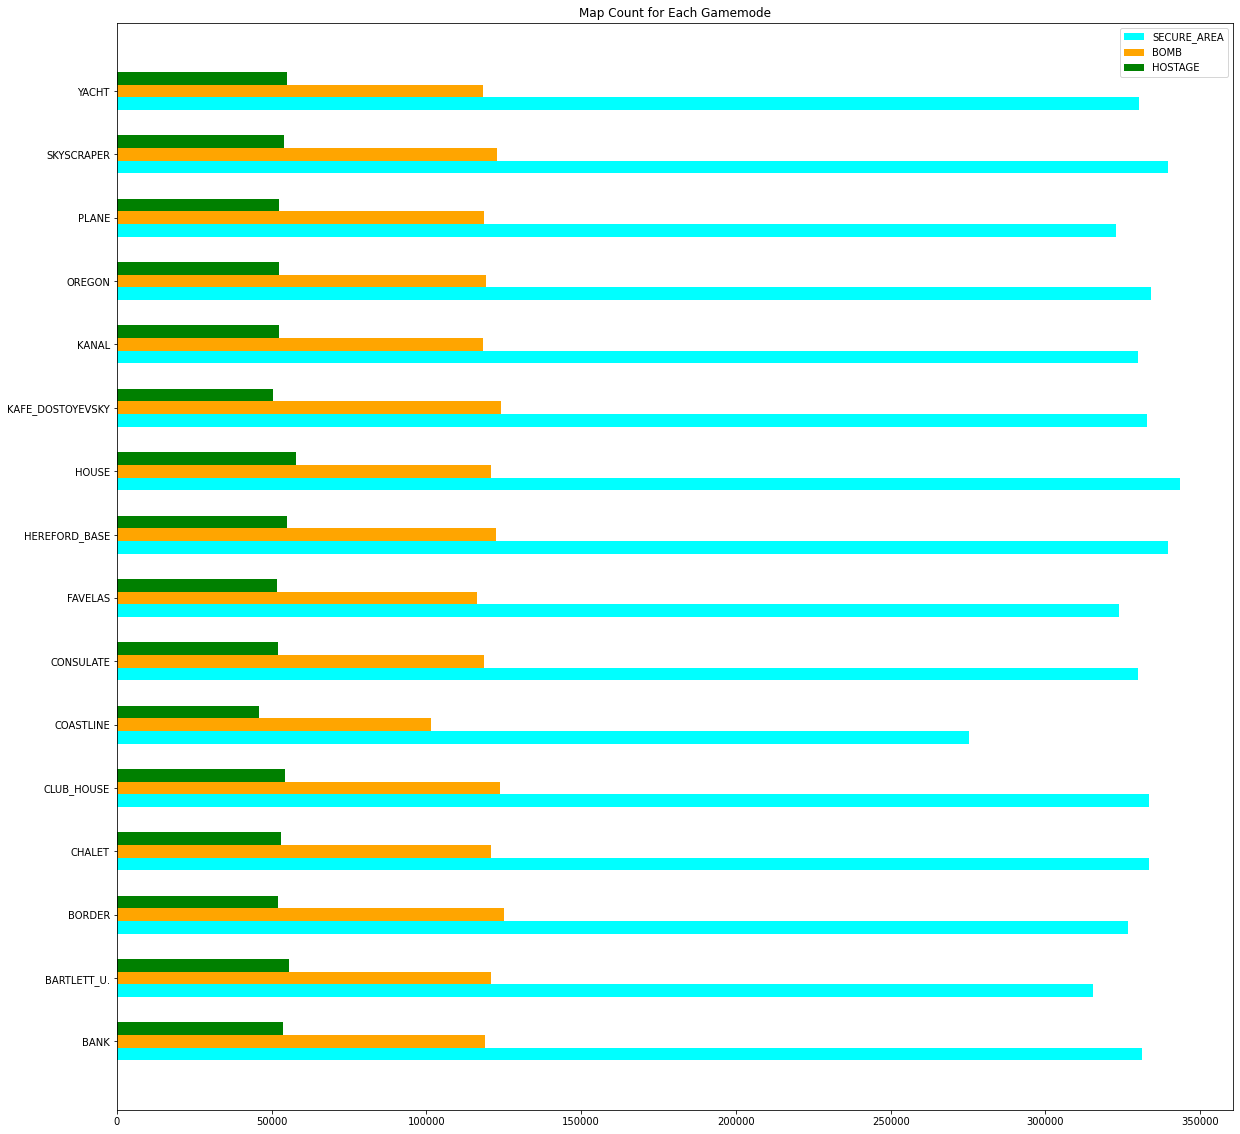

In [13]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(16)
width = 0.2
  
# plot data in grouped manner of bar type
plt.figure(figsize=(20,20))
plt.barh(x-0.2, sec_map_count, width, color='cyan')
plt.barh(x, bom_map_count, width, color='orange')
plt.barh(x+0.2, hos_map_count, width, color='green')
plt.yticks(x, hos_map_count.index)
plt.title('Map Count for Each Gamemode')
plt.legend(['SECURE_AREA', 'BOMB', 'HOSTAGE'])
plt.show()

In [14]:
# we can see that the hostage is the least and bomb is the second most and the secure area gamemode is the most played

In [15]:
'''so the possiblities are either the game algorithm is selecting secure area more times 
or 
the number of rounds players play is more in securearea which could 
mean that it is either attackers win or the defenders win'''
#so now comparing the winrole with the gamemode as the second case could mean that we need changes accordingly

'so the possiblities are either the game algorithm is selecting secure area more times \nor \nthe number of rounds players play is more in securearea which could \nmean that it is either attackers win or the defenders win'

In [16]:
sec_role_count = sec_gm.groupby('winrole')['gamemode'].count()
bom_role_count = bom_gm.groupby('winrole')['gamemode'].count()
hos_role_count = hos_gm.groupby('winrole')['gamemode'].count()
print(sec_role_count,bom_role_count,hos_role_count)

winrole
Attacker    2647331
Defender    2594326
Name: gamemode, dtype: int64 winrole
Attacker    955128
Defender    956003
Name: gamemode, dtype: int64 winrole
Attacker    392764
Defender    454448
Name: gamemode, dtype: int64


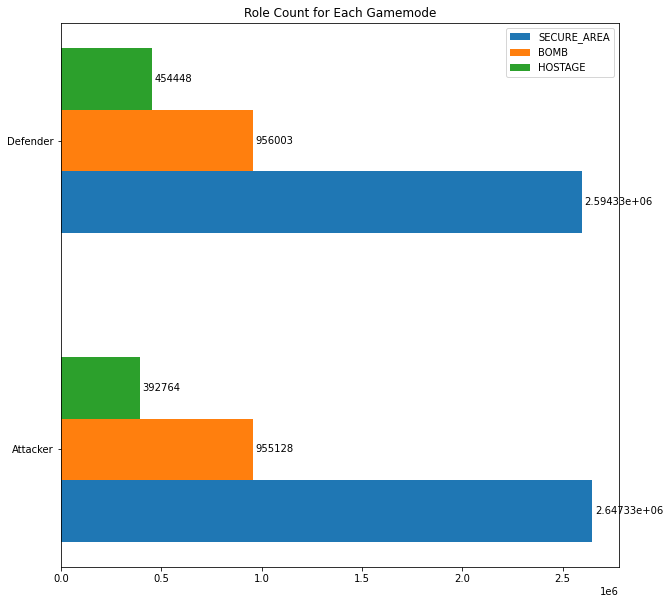

In [17]:
y = np.arange(2)

width = 0.20


fig, ax = plt.subplots(figsize=(10,10))
rects1 = ax.barh(y - width, sec_role_count, width, label='SECURE_AREA')
rects2 = ax.barh(y, bom_role_count, width, label='BOMB')
rects3 = ax.barh(y + width, hos_role_count, width, label='HOSTAGE')


ax.set_title('Role Count for Each Gamemode')
ax.set_yticks(y, hos_role_count.index)
ax.legend(loc='best')
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)
ax.bar_label(rects3, padding=3)
plt.show()

In [18]:
'''Everygame mode is almost equal for both attackers and defenders whereas the hostage mode we can see that 
the defenders are comparitively winning more so rules could be a little bit changed to make it equally difficult'''

'Everygame mode is almost equal for both attackers and defenders whereas the hostage mode we can see that \nthe defenders are comparitively winning more so rules could be a little bit changed to make it equally difficult'

In [19]:
# 2) which operators are taken frequently and which are the least preferred ones
# this could be very useful and can buff and nerf in the future patches accordingly

In [20]:
df.groupby('operator').count()

,dateid,platform,gamemode,mapname,matchid,roundnumber,objectivelocation,winrole,endroundreason,roundduration,...,primarygrip,primaryunderbarrel,primarybarrel,secondaryweapon,secondaryweapontype,secondarysight,secondarygrip,secondaryunderbarrel,secondarybarrel,secondarygadget
operator,,,,,,,,,,,,,,,,,,,,,
BOPE-CAPITAO,123113,123113,123113,123113,123113,123113,123113,123113,123113,123113,...,123113,123113,123113,123113,123113,123113,123113,123113,123113,123113
BOPE-CAVEIRA,362881,362881,362881,362881,362881,362881,362881,362881,362881,362881,...,362881,362881,362881,362881,362881,362881,362881,362881,362881,362881
G.E.O.-JACKAL,335600,335600,335600,335600,335600,335600,335600,335600,335600,335600,...,335600,335600,335600,335600,335600,335600,335600,335600,335600,335600
G.E.O.-MIRA,268986,268986,268986,268986,268986,268986,268986,268986,268986,268986,...,268986,268986,268986,268986,268986,268986,268986,268986,268986,268986
GIGN-DOC,218811,218811,218811,218811,218811,218811,218811,218811,218811,218811,...,218811,218811,218811,218811,218811,218811,218811,218811,218811,218811
GIGN-MONTAGNE,140137,140137,140137,140137,140137,140137,140137,140137,140137,140137,...,140137,140137,140137,140137,140137,140137,140137,140137,140137,140137
GIGN-RESERVE,13995,13995,13995,13995,13995,13995,13995,13995,13995,13995,...,13995,13995,13995,13995,13995,13995,13995,13995,13995,13995
GIGN-ROOK,261890,261890,261890,261890,261890,261890,261890,261890,261890,261890,...,261890,261890,261890,261890,261890,261890,261890,261890,261890,261890
GIGN-TWITCH,390928,390928,390928,390928,390928,390928,390928,390928,390928,390928,...,390928,390928,390928,390928,390928,390928,390928,390928,390928,390928


In [21]:
df.groupby('operator')['operator'].count()

operator
BOPE-CAPITAO           123113
BOPE-CAVEIRA           362881
G.E.O.-JACKAL          335600
G.E.O.-MIRA            268986
GIGN-DOC               218811
GIGN-MONTAGNE          140137
GIGN-RESERVE            13995
GIGN-ROOK              261890
GIGN-TWITCH            390928
GSG9-BANDIT            400048
GSG9-BLITZ              59520
GSG9-IQ                124295
GSG9-JAGER             540882
GSG9-RESERVE            47681
JTF2-BUCK              186781
JTF2-FROST             271786
NAVYSEAL-BLACKBEARD    144567
NAVYSEAL-VALKYRIE      323472
SAS-MUTE               305448
SAS-RESERVE             32148
SAS-SLEDGE             307905
SAS-SMOKE              264878
SAS-THATCHER           243420
SAT-ECHO                85625
SAT-HIBANA             387329
SPETSNAZ-FUZE          351101
SPETSNAZ-GLAZ          260567
SPETSNAZ-KAPKAN        176230
SPETSNAZ-RESERVE        13141
SPETSNAZ-TACHANKA       32600
SWAT-ASH               493068
SWAT-CASTLE            168662
SWAT-PULSE             265389
S

In [22]:
#we can go with pie chart but I am not preferring it as there are lot of operator and data wont be proper so proceeding with barchart

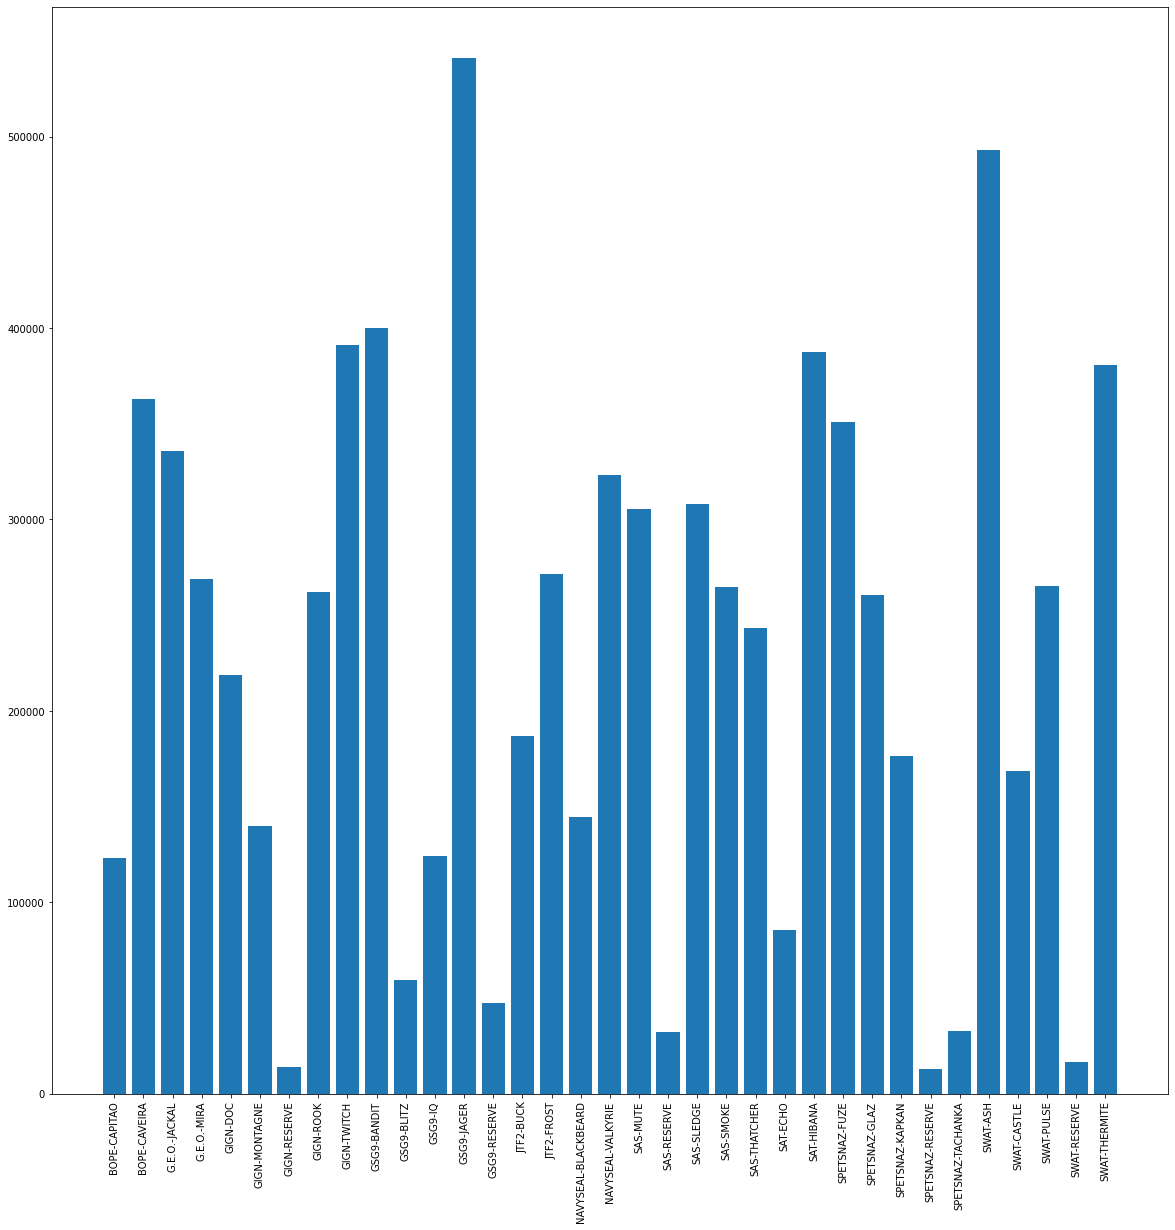

In [23]:
plt.figure(figsize=(20,20))
plt.bar(df.groupby('operator')['operator'].count().index,df.groupby('operator')['operator'].count())
plt.xticks(rotation = 90)
plt.show()

In [24]:
# we can see jager(defender) and ash(attacker) are most preffered ones so they can be nerfed
# and also we can see that recruit aka reserve a basic operator is not preffered which is fine
# and also we can see tachanka(defender) and blitz(attacker) are least preffered ones so they can get a buff

# comparing map with round duration

In [25]:
round_dur_map = df.groupby('mapname')['roundduration'].mean().sort_values(ascending = False)

In [26]:
round_dur_map

mapname
BARTLETT_U.         192.896611
BANK                191.647094
OREGON              189.798997
CLUB_HOUSE          189.711203
CONSULATE           189.580556
KANAL               189.493007
HEREFORD_BASE       187.909268
KAFE_DOSTOYEVSKY    187.878560
PLANE               187.342444
COASTLINE           184.889465
BORDER              184.259530
YACHT               183.024594
HOUSE               181.603751
CHALET              181.422134
SKYSCRAPER          180.184330
FAVELAS             176.393326
Name: roundduration, dtype: float64

In [27]:
'''From this data we can see that Bartlett and Bank is taking more time and Favela is taking less time
for a round, so the maps can be altered or the objective location could be made nearby or far to make them 
fall between 180 to 190 seconds
'''

'From this data we can see that Bartlett and Bank is taking more time and Favela is taking less time\nfor a round, so the maps can be altered or the objective location could be made nearby or far to make them \nfall between 180 to 190 seconds\n'

# comparing objective location with duration

In [28]:
# For some maps the objective location names are same, so its better to use pivot table

In [29]:
pv_table = pd.pivot_table(df,index=['mapname', 'objectivelocation'],values='roundduration',aggfunc = 'mean').sort_values('roundduration',ascending=False)
pv_table

roundduration
mapname     objectivelocation                     
BARTLETT_U. LIBRARY                     201.131483
            CLASSROOM-LIBRARY           198.071277
COASTLINE   2F_PENTHOUSE-2F_THEATER     196.869155
BANK        VAULT                       196.498358
CLUB_HOUSE  CHURCH                      196.432030
...                                            ...
HOUSE       KID'S_BEDROOM               168.709865
FAVELAS     3F_PACKAGING_ROOM           168.667296
SKYSCRAPER  1F_KITCHEN                  168.256655
HOUSE       DINING_ROOM                 167.421708
            LIVING_ROOM                 164.551883

[160 rows x 1 columns]

In [30]:
#Finding the objectives location for the time reduction steps by keeping a threshold of 190
pv_table[(pv_table['roundduration']>190) | (pv_table['roundduration']<180)]

roundduration
mapname     objectivelocation                     
BARTLETT_U. LIBRARY                     201.131483
            CLASSROOM-LIBRARY           198.071277
COASTLINE   2F_PENTHOUSE-2F_THEATER     196.869155
BANK        VAULT                       196.498358
CLUB_HOUSE  CHURCH                      196.432030
...                                            ...
HOUSE       KID'S_BEDROOM               168.709865
FAVELAS     3F_PACKAGING_ROOM           168.667296
SKYSCRAPER  1F_KITCHEN                  168.256655
HOUSE       DINING_ROOM                 167.421708
            LIVING_ROOM                 164.551883

[89 rows x 1 columns]

In [31]:
pd.set_option('display.max_rows',100)

In [32]:
needed_pv_table = pv_table[(pv_table['roundduration']>190) | (pv_table['roundduration']<180)]

In [33]:
'''So for these objective the difficulty level should be reduced if it take more than 190 seconds 
and if its less than 180 second difficulty level should be increased'''

'So for these objective the difficulty level should be reduced if it take more than 190 seconds \nand if its less than 180 second difficulty level should be increased'

# saving it as a csv file for future use

In [34]:
needed_pv_table.to_csv('changes_needed_objectivelocations')

In [35]:
pd.set_option('display.max_rows',10)

# comparing the endroundreason with objectivelocation

In [36]:
end_obj = pd.crosstab(df["objectivelocation"], df["endroundreason"])
end_obj

endroundreason,AllTeamsDead,AttackersEliminated,AttackersKilledHostage,AttackersSurrendered,BombDeactivated_OneBomb,BombExploded,DefendersEliminated,DefendersKilledHostage,DefendersSurrendered,DefuserDeactivated,HostageExtracted,NoEnemies,ObjectiveCaptured,ObjectiveProtected,TimeExpired
objectivelocation,,,,,,,,,,,,,,,
1F_ARMORY_ROOM,69,39539,0,141,0,0,42707,0,61,0,0,1,4892,2604,0
1F_AUNT'S_APARTMENT,64,21469,0,147,0,0,26115,0,42,0,0,2,3260,2919,0
1F_BBQ,10,21241,0,113,0,0,20376,0,32,0,0,5,2940,1375,0
1F_BBQ-1F_KITCHEN,8,5700,0,14,310,605,7694,0,16,1159,0,5,0,0,0
1F_BEDROOM,85,24777,265,129,0,0,27151,207,67,0,1586,5,5052,1274,339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VENTILATION_ROOM-WORKSHOP,10,9685,0,34,656,1848,12031,0,25,2136,0,0,0,0,0
VISA_OFFICE,10,5453,0,16,0,0,7288,0,39,0,0,6,2224,665,0
WINE_CELLAR,0,9057,563,19,0,0,8448,323,6,0,1473,0,0,0,1520


In [37]:
# we can use this data and do any analysis we need
# checking Time expired is more in which objectivelocation
time_exp_obj = end_obj['TimeExpired'].sort_values(ascending = False)
time_exp_obj

objectivelocation
KITCHEN                            3875
VAULT                              3680
MASTER_BEDROOM                     3410
CHURCH                             2592
ARMORY                             2591
                                   ... 
DUMMY_DEPOT-STORAGE                   0
DINING_ROOM-KIDS_BEDROOM              0
DINING_HALL                           0
CUSTOMS_INSPECTIONS-SUPPLY_ROOM       0
1F_ARMORY_ROOM                        0
Name: TimeExpired, Length: 142, dtype: int64

([<matplotlib.patches.Wedge at 0x7f59a9898fd0>,
 [Text(0.8019416752072347, 0.752920679464852, 'KITCHEN'),
  Text(-0.6682501456631612, 0.8737515338018951, 'VAULT'),
  Text(-0.9849376288598184, -0.4897936986691426, 'MASTER_BEDROOM'),
  Text(0.06416495438866114, -1.098126977461305, 'CHURCH'),
  Text(0.9631816499183486, -0.5313013356472651, 'ARMORY')],
 [Text(0.4374227319312189, 0.41068400698082835, '24.00%'),
  Text(-0.36450007945263335, 0.4765917457101245, '22.79%'),
  Text(-0.53723870665081, -0.26716019927407775, '21.12%'),
  Text(0.0349990660301788, -0.5989783513425299, '16.05%'),
  Text(0.5253718090463719, -0.2898007285348719, '16.05%')])

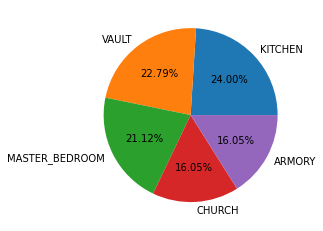

In [38]:
plt.pie(time_exp_obj.head(5), labels = time_exp_obj.head(5).index, autopct="%1.2f%%")

In [39]:
#So these places need size increase to avoid time getting over as end round reason and also we could set a threshold instead of top 5

([<matplotlib.patches.Wedge at 0x7f59a9815550>,
 [Text(0.7389123192762674, 0.8148672188901499, 'GARAGE'),
  Text(-0.8483468273060901, 0.7002197230867544, 'ARCHIVES'),
  Text(-0.8860934787828263, -0.651796246428705, 'MASTER_BEDROOM'),
  Text(0.1445651872499553, -1.090459034826795, 'WORKSHOP'),
  Text(0.9876576718937112, -0.4842853736687641, 'LIBRARY')],
 [Text(0.4030430832416004, 0.44447302848553627, '26.55%'),
  Text(-0.4627346330760491, 0.38193803077459326, '24.93%'),
  Text(-0.4833237156997233, -0.3555252253247482, '17.23%'),
  Text(0.0788537384999756, -0.5947958371782518, '16.78%'),
  Text(0.5387223664874787, -0.2641556583647804, '14.51%')])

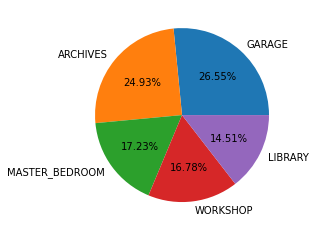

In [40]:
# Attackers surrendered and defenders surrendered
att_sur_obj = end_obj['AttackersSurrendered'].sort_values(ascending = False)
plt.pie(att_sur_obj.head(5), labels = att_sur_obj.head(5).index, autopct="%1.2f%%")

In [41]:
#These can be made easy to attack

([<matplotlib.patches.Wedge at 0x7f59a978c450>,
 [Text(0.6562493337772012, 0.8828005504738767, 'GARAGE'),
  Text(-0.9189754782786367, 0.604552785389788, 'ARCHIVES'),
  Text(-0.8845899314456604, -0.6538353410339349, 'SNOWMOBILE_GARAGE'),
  Text(0.10202331056328078, -1.0952585284313967, 'LOCKERS'),
  Text(0.9724935478300567, -0.5140586536854617, '2F_WORK_OFFICE')],
 [Text(0.35795418206029156, 0.4815275729857509, '29.65%'),
  Text(-0.5012593517883472, 0.3297560647580661, '22.17%'),
  Text(-0.4825035989703602, -0.3566374587457826, '16.61%'),
  Text(0.05564907848906223, -0.5974137427807618, '16.09%'),
  Text(0.5304510260891218, -0.28039562928297906, '15.48%')])

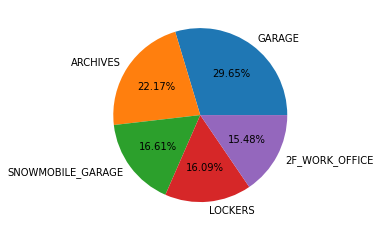

In [42]:
def_sur_obj = end_obj['DefendersSurrendered'].sort_values(ascending = False)
plt.pie(def_sur_obj.head(5), labels = def_sur_obj.head(5).index, autopct="%1.2f%%")

In [43]:
#These objectives can be made easy to defend

Text(0, 0.5, 'DefendersKilledHostage')

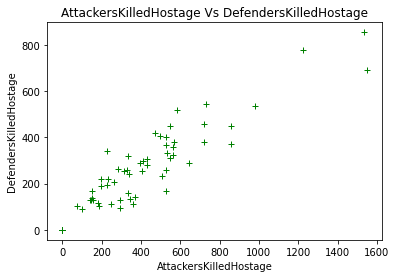

In [44]:
# comparing AttackersKilledHostage and DefendersKilledHostage
att_kill_hos = end_obj['AttackersKilledHostage']
def_kill_hos = end_obj['DefendersKilledHostage']
plt.plot(att_kill_hos,def_kill_hos,'g+')
plt.title('AttackersKilledHostage Vs DefendersKilledHostage')
plt.xlabel('AttackersKilledHostage')
plt.ylabel('DefendersKilledHostage')

In [45]:
#we can see that It is almost the same number of times hostage was killed by both attackers and defenders

In [46]:
#Finding the correlation between all of them
df.drop(['dateid','matchid'],axis=1).corr()

,roundnumber,roundduration,clearancelevel,team,haswon,nbkills,isdead
roundnumber,1.000000,0.005309,0.025621,-0.000821,0.004358,-0.003359,-0.005923
roundduration,0.005309,1.000000,0.055102,-0.000150,-0.011683,0.060025,0.118866
clearancelevel,0.025621,0.055102,1.000000,0.008847,0.025301,0.069960,-0.017778
team,-0.000821,-0.000150,0.008847,1.000000,-0.005644,-0.002974,0.005273
haswon,0.004358,-0.011683,0.025301,-0.005644,1.000000,0.249184,-0.564573
nbkills,-0.003359,0.060025,0.069960,-0.002974,0.249184,1.000000,-0.365543
isdead,-0.005923,0.118866,-0.017778,0.005273,-0.564573,-0.365543,1.000000


<AxesSubplot:>

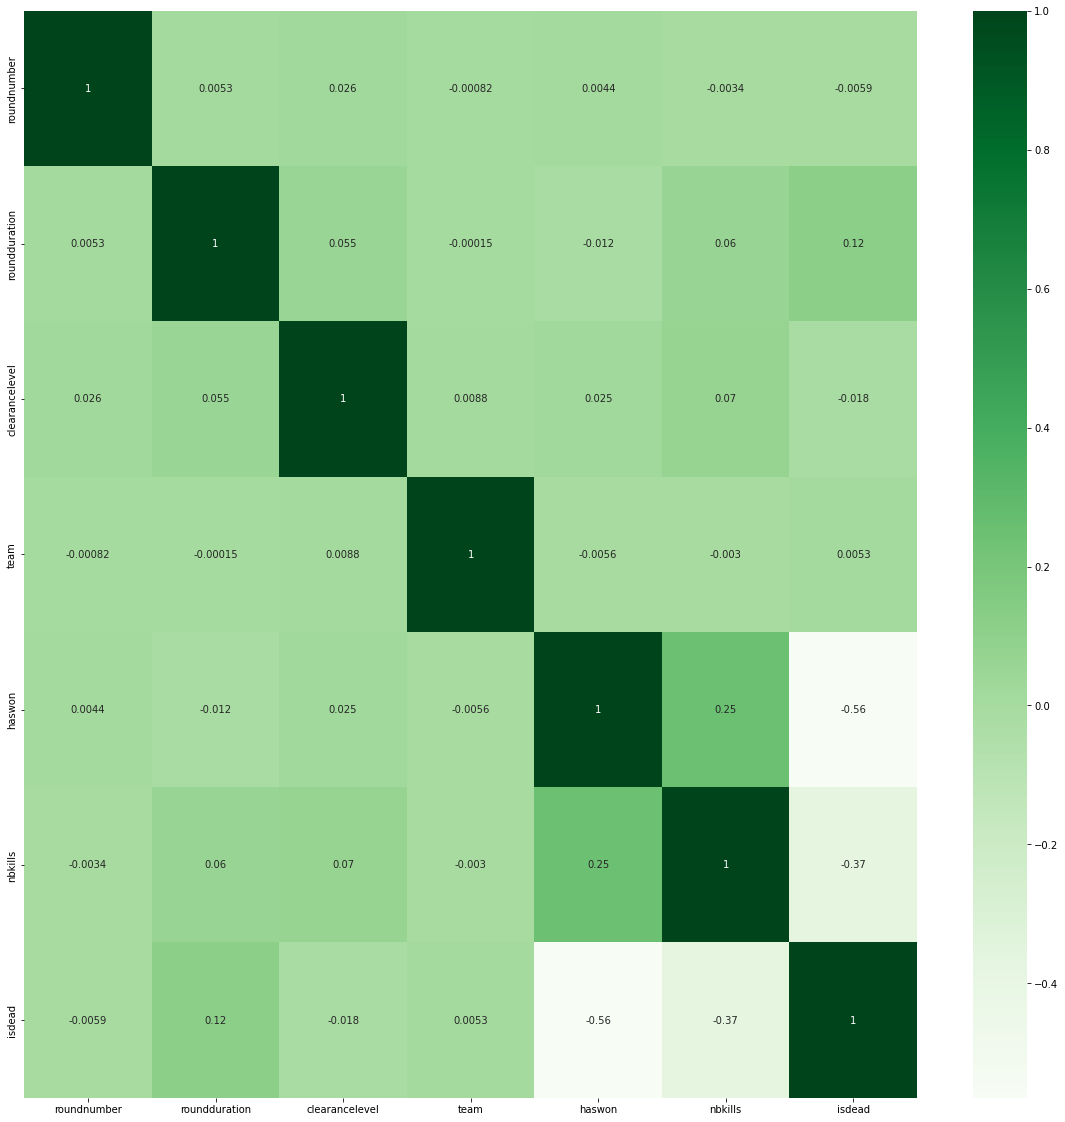

In [47]:
#For a better understanding of correlation using heatmap
fig, ax = plt.subplots(figsize=(20, 20))
sns.heatmap(df.drop(['dateid','matchid'],axis=1).corr(),cmap = 'Greens',annot=True)

# Which primary weapon type is frequently used and least preferred

<AxesSubplot:xlabel='count', ylabel='primaryweapontype'>

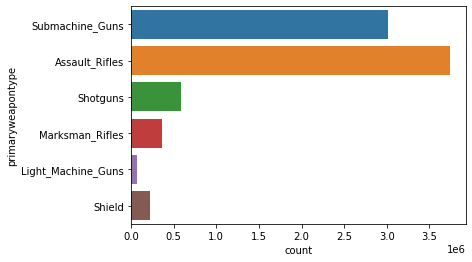

In [48]:
sns.countplot(y ='primaryweapontype', data = df)

In [49]:
# we can see that Light maachine guns are least preffered(needs buff) and assault rifles are most preffered ones(needs nerf)

In [50]:
#finding the most prefferd primary weapon secondry weapon combo using number of kills as a criteria
pd.pivot_table(df,index=['primaryweapon', 'secondaryweapon'],values='nbkills',aggfunc = 'sum').sort_values('nbkills',ascending=False)

,,nbkills
primaryweapon,secondaryweapon,
416-C_CARBINE,P12,436515
MP7,P12,284899
TYPE-89,BEARING_9,256787
R4-C,M45_MEUSOC,218795
MPX,D-50,199512
...,...,...
Shield,GSH-18,1925
ITA12L,ITA12S,1842
MP5K,SMG-11,1476


In [51]:
# we can clearly see that 416-C_CARBINE and P12 combo is very powerful compared to others so some nerf should take place
# Also we can see that SuperNova and p229 is at the last so some buff can be given in the future patch

In [52]:
df.skillrank.unique()

array(['Gold', 'Platinum', 'Diamond', 'Unranked', 'Silver', 'Bronze',
       'Copper'], dtype=object)

In [53]:
df.haswon.unique()

array([0, 1])

In [54]:
df.haswon = df.haswon.map({0:'Lost', 1:'Won'})

In [55]:
df.haswon.unique()

array(['Lost', 'Won'], dtype=object)

# comparing the skill rank with the winning and losing

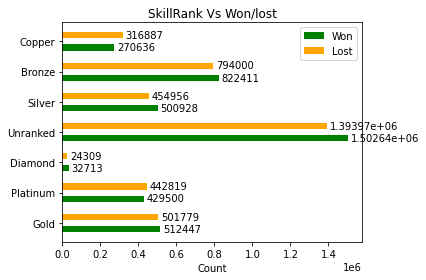

In [56]:

won = df[df['haswon'] == 'Won']
lost = df[df['haswon'] == 'Lost']


y = np.arange(7)
won_count = won.groupby('skillrank')['haswon'].count()
lost_count = lost.groupby('skillrank')['haswon'].count()
width = 0.2

fig, ax = plt.subplots()
rects1 = ax.barh(y - width, won_count, width, label='Won', color = 'Green')
rects2 = ax.barh(y + width, lost_count, width, label='Lost', color = 'orange')


ax.set_title('SkillRank Vs Won/lost')
ax.set_yticks(y, df.skillrank.unique())
ax.legend()

ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)
ax.set_xlabel('Count')
fig.tight_layout()

plt.show()

In [57]:
# We can see that its almost the same won/lost times

In [58]:
#This is the end of my analysis